In [1]:
# PESTO ETC
# Francois-Rene Lachapelle : lachapelle@astro.umontreal.ca

# Detector :
# certificat de conformité : 2018.04.20 (anciennement 2014.03.12)
# HNü 1024
# SN90013-11-T102-01
# Thermoelectric; down to -90◦C with 20◦C liquid cooling, down to -80◦C with air cooling. Temperature stabilized at ±0.01◦C
# E2V / CCD201-20-1-122 SN12231-01-17
# 1024 × 1024; Frame transfer; 13μm × 13μm pixel; 177.2mm2 effective area
# Grade 1; Broadband coating
from __future__ import print_function

In [2]:
%matplotlib inline
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from astropy import time, coordinates as coord, units as u
from scipy import special
import ipywidgets as widgets
from IPython.display import display

In [3]:
# input
mag     =  10.   # target magnitude in observed band
ttot    = 60.    # [s]
fwhm    =   2.    # seeing (IQ) [arcsec] (1 - 10, defautl=2)
am      =   1.5   # air mass (< 3)
texp    = 1069.  # [ms]  (default: 1069 in Conv, 115 in EM, 10 in PC)
mode    = 'Conv'  # ('Conv','EM','PC')
em_gain =   1.    # (1 in Conv, 10 to 1000 in EM, 3000 to 5000 in PC)
temp    = -85.    # [°C] (-60 to -90 default=-85)
band    =  'i'    # ('g','r','i','z','Ha','open')


wmag=widgets.FloatText(
    description='mag = ',
    value=10.,
    disabled=False
)
display(wmag)

wfilter=widgets.Dropdown(
    options={"g'":'g',"r'":'r',"i'":'i',"zs":'z','H-alpha':'Ha', 'open':'open'},
    value='i',
    description='Filter',
    disabled=False
)
display(wfilter)

wmode=widgets.RadioButtons(
    options={'Conventional':'Conv', 'EM':'EM', 'Photon counting':'PC'},
    value='Conv',
    description='Mode',
    disabled=False
)
display(wmode)

wtexp=widgets.BoundedIntText(
    value=1069,
    min=5,
    max=1200000,
    step=1,
    description='Exposure time [ms]',
    disabled=False
)
display(wtexp)

wttot=widgets.FloatText(
    description='Coadd time [s]',
    disabled=False
)
display(wttot)

wem=widgets.IntSlider(
    value=1,
    min=1,
    max=1,
    step=1,
    description='EM gain',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)
    
def on_value_change(change):
    global wem
    if change['new']=='EM':
        wem=widgets.IntSlider(
            value=100,
            min=10,
            max=1000,
            step=1,
            description='EM gain',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            readout=True,
            readout_format='d'
        )
        display(wem)
    elif change['new']=='PC':
        wem=widgets.IntSlider(
            value=5000,
            min=3000,
            max=5000,
            step=1,
            description='EM gain',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            readout=True,
            readout_format='d'
        )
        display(wem)
    elif change['new']=='Conv':
        wem=widgets.IntSlider(
            value=1,
            min=1,
            max=1,
            step=1,
            description='EM gain',
            disabled=False,
            continuous_update=False,
            orientation='horizontal',
            readout=True,
            readout_format='d'
        )
        display(wem)
wmode.observe(on_value_change, names='value')

wam=widgets.FloatSlider(
    value=1.5,
    min=1.,
    max=3.,
    step=0.1,
    description='Air mass',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f'
)
display(wam)

wiq=widgets.FloatSlider(
    value=2.,
    min=1.,
    max=10.,
    step=0.1,
    description='IQ [arcsec]',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f'
)
display(wiq)

wtemp=widgets.IntSlider(
    value=-85,
    min=-90,
    max=-60,
    step=5,
    description='CCD Temperature [C]',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='d'
)
display(wtemp)


FloatText(value=10.0, description='mag = ')

Dropdown(description='Filter', index=2, options={"g'": 'g', "r'": 'r', "i'": 'i', 'zs': 'z', 'H-alpha': 'Ha', …

RadioButtons(description='Mode', options={'Conventional': 'Conv', 'EM': 'EM', 'Photon counting': 'PC'}, value=…

BoundedIntText(value=1069, description='Exposure time [ms]', max=1200000, min=5)

FloatText(value=0.0, description='Coadd time [s]')

FloatSlider(value=1.5, continuous_update=False, description='Air mass', max=3.0, min=1.0, readout_format='.1f'…

FloatSlider(value=2.0, continuous_update=False, description='IQ [arcsec]', max=10.0, min=1.0, readout_format='…

IntSlider(value=-85, continuous_update=False, description='CCD Temperature [C]', max=-60, min=-90, step=5)

Button(description='Calculate', style=ButtonStyle())

0.00016951677744426853
Detector Temperature [°C] :   -85
Observation mode          :    Conv
Observation band          :     i
Exposure time [ms]        : 30000
EM gain                   :     1
Roi size [lines]          :  1024  

Target magnitude          :    14.4
IQ [arcsec]               :     2.0
Air mass                  :     1.5
Total exposure [s]        :    30.000
Images to coadd           :     1  
Phot. aperture area [px]  :    26.5
Aperture radius [FWHM]    :     0.67

Total signal [adu]           :     37689.67
Signal per image [adu]       :     37689.67
Brightest pixel [adu]        :      2011 
Sky brightness [adu]         :       344 
Saturation [adu/px]          :     15746 
Saturation time [ms]         :    235841 
Saturation em_gain           :       nan 
Saturation magnitude         :        12.12
Saturation magnitude at AM=1 :        12.17

Signal to noise ratio    :       433.38
Phot. error [mmag]       :         2.50
Flux [e-/exposure]       :    198209.99
Total

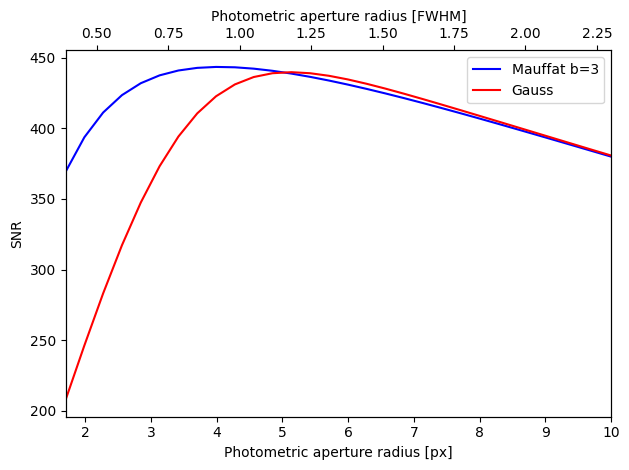

In [4]:
button = widgets.Button(description="Calculate")
display(button)

def on_button_clicked(b):
    
    
    mag     =  wmag.value   # target magnitude in observed band
    ttot    =  wttot.value    # [s]
    fwhm    =  wiq.value     # seeing (IQ) [arcsec] (1 - 10, defautl=2)
    am      =  wam.value    # air mass (< 3)
    texp    =  wtexp.value   # [ms]  (default: 1069 in Conv, 115 in EM, 10 in PC)
    mode    =  wmode.value   # ('Conv','EM','PC')
    em_gain =  wem.value     # (1 in Conv, 10 to 1000 in EM, 3000 to 5000 in PC)
    temp    =  wtemp.value     # [°C] (-60 to -90 default=-85)
    band    =  wfilter.value     # ('g','r','i','z','Ha','open')

    # input verification
    if am   <   1. : am   =   1.
    if am   >   3. : am   =   3.
    if temp < -90  : temp = -90
    if temp > -60  : temp = -60
    if texp <   5. : texp =   5.

    # Exposures
    texp/=1000. # [ms/s]
    n_read = np.floor(ttot/texp)
    if n_read == 0. : 
        n_read, ttot = 1., texp

    # +++++++++++++++++++
    # observed flux at 20 mag, am=1, texp=1s
    if   band=='g'   : 
        n20 = 78.0 # [e-/s]
        am_coef =  0.4 # extinction magnitude / air mass
        sky_mag = 22.1 # [mag/arcsec^2]
    elif band=='r'   : 
        n20 = 67.9 # [e-/s]
        am_coef =  0.15 # extinction magnitude / air mass
        sky_mag = 21.1 # [mag/arcsec^2]
    elif band=='i'   : 
        n20 = 43.9 # [e-/s]
        am_coef =  0.1 # extinction magnitude / air mass
        sky_mag = 20.2 # [mag/arcsec^2]
    elif band=='z'   : 
        n20 = 11.8 # [e-/s]
        am_coef =  0.1 # extinction magnitude / air mass
        sky_mag = 18.3 # [mag/arcsec^2]
    elif band=='Ha'  : 
        n20 =   .1 # [e-/s]                         
        am_coef =  .15 # extinction magnitude / air mass
        sky_mag = 21. # [mag/arcsec^2]
    elif band=='open': 
        n20 =   100. # [e-/s]                       
        am_coef =  .2 # extinction magnitude / air mass
        sky_mag = 21. # [mag/arcsec^2]
    #++++++++++++++++++++++++++++++++

    # Dark current
    mm,cc = 0.063223437503356419, 1.6032048755213368 # interpolation of measured dark(temp)
    temp_vec = np.linspace(-100, -50, num=51, endpoint=True)
    dark_vec = 10.**(mm*temp_vec + cc)
    dark = float(dark_vec[np.where(temp_vec==round(temp))])
    print(dark)
    # Readout modes
    if mode == 'EM':
        tfull     = 115.109341 # [ms]
        rn        = 81.98 # [e-/px/read]
        full_well = 80629 # [e-]
        k_gain    = 13.522 # [e-/adu]
        if em_gain <   10. : em_gain =   10.
        if em_gain > 1000. : em_gain = 1000.
        cic       = .0014514 # [e-/px/im]
    if mode == 'Conv': 
        tfull     = 1069.290095 # [ms]
        rn        = 13.25 # [e-/px/read]
        full_well = 81232 # [e-]
        k_gain    = 5.259 # [e-/adu]
        em_gain   = 1.
        cic       = .0106600 # [e-/px/im]
    if mode == 'PC':
        tfull     = 115.109341 # [ms]
        rn        = 81.98 # [e-/px/read]
        full_well = 80629 # [e-]
        k_gain    = 13.522 # [e-/adu]
        if em_gain < 3000. : em_gain = 3000.
        if em_gain > 5000. : em_gain = 5000.
        cic       = .0018862 # [e-/px/im]
    clamp   = 300 # [adu]
    Nlines  = 1024.
    px_scl  = .46 # [arcsec/px]

    # Photometric aperture
    aper = 1.4 * (fwhm/px_scl)**2. # [px]
    #aper = np.pi * (1.*fwhm/px_scl)**2.
    if aper < 9. : aper = 9.
    r_aper      = np.sqrt(aper/np.pi)
    r_aper_fwhm = np.sqrt(aper/np.pi) * px_scl/fwhm

    # fraction of the flux in the aperture
    # Moffat
    alpha = .5 * fwhm/px_scl
    beta  = 3. 
    faper = 1 - (1 + (r_aper/alpha)**2.)**(1.-beta)
    # Gauss
    #faper = special.erf(r_aper * 1.662 * px_scl/fwhm)**2.

    # maximum flux fraction in 1 pixel
    # Moffat
    #f1px = 1 - (1 + (2.**(1./beta)-1) * (0.5**2. / alpha**2.))**(1.-beta)
    # Gauss
    f1px  = special.erf(0.5    * 1.662 * px_scl/fwhm)**2. # +2%/-5% à r_aper->0 - voir simulation dans f1px.pro

    # Size of region of interest
    n_line = int(round(texp/((tfull/1000.)/Nlines)))
    if n_line > int(round(Nlines)) : n_line = int(round(Nlines))

    # Flux
    mag_obs  = mag + am_coef * (am - 1.)
    nn       = n20 * 10**((20.-mag_obs)/2.5)
    flux     = nn * texp * faper
    flux_tot = flux * n_read
    sky      = n20 * (px_scl**2) * 10**((20.-sky_mag)/2.5)
    sky     *= texp

    # Noise
    phot_noise = np.sqrt(flux_tot) * em_gain
    sky_noise  = np.sqrt(sky * aper * n_read) * em_gain
    cic_noise  = np.sqrt(cic * aper * n_read) * em_gain
    if mode == 'PC' : 
        cic_noise = 0.
    dark_noise = np.sqrt(dark * aper * n_read * texp) * em_gain
    if mode == 'PC' : 
        dark_noise = 0.
    if mode == 'PC' : 
        rn        = 0.
    eff_rn     = np.sqrt(rn**2. + (k_gain/2.)**2.)  #AY 257 – Modern Observational Techniques: Signal-to-Noise in Optical Astronomy
    r_noise    = np.sqrt(eff_rn**2 * aper * n_read) #AY 257 – Modern Observational Techniques: Signal-to-Noise in Optical Astronomy

    # SNR
    signal    = flux_tot * em_gain
    noise_tot = np.sqrt(phot_noise**2. + sky_noise**2. + r_noise**2. + cic_noise**2. + dark_noise**2.)
    snr       = signal / noise_tot
    phot_err  = 2.5 * np.log10(1. + 1./snr) *1000. # mmag  #AY 257 – Modern Observational Techniques: Signal-to-Noise in Optical Astronomy
    eff_noise = noise_tot / em_gain # noise equivalent at em_gain = 1

    # Image statistics
    exp_adu = flux * em_gain/k_gain        # [adu/exposure]
    tot_adu = exp_adu * n_read             # [adu]
    px_max  = flux * f1px * em_gain        # [e-/px/exposure]
    max_adu = clamp + px_max/k_gain        # [adu/px/exposure]
    sky_adu = clamp + sky * em_gain/k_gain # [adu/px/exposure]

    # Observation statistics
    sat_adu     = full_well/k_gain + clamp # [adu/px]
    if mode == 'PC' : 
        sat_adu = 1. * em_gain/k_gain  + clamp # un flux de 1 e-/px en [adu/px]
    sat_flux    = (sat_adu - clamp)/texp * (k_gain/em_gain) / f1px
    sat_time    = sat_flux/nn *texp *1000
    sat_mag     = 20. - 2.5* np.log10(sat_flux / n20) - am_coef * (am - 1.) 
    sat_mag_1am = 20. - 2.5* np.log10(sat_flux / n20)  # at aimass = 1
    sat_gain    = (sat_adu - clamp) * k_gain / (flux * f1px)
    if mode == 'PC' : # la saturation depend du flux et donc pas du gain, mais un gain eleve peut depasser le full_well
        sat_gain= full_well / (flux * f1px) # saturation du full_well pour a 1 e-/px
    if mode == 'Conv' : 
        sat_gain= np.nan
          
    print("Detector Temperature [°C] : {:5.0f}".format(temp))
    print("Observation mode          :    {:s}".format(mode))
    print("Observation band          :     {:s}".format(band))
    print("Exposure time [ms]        : {:5.0f}".format(texp*1000.))
    print("EM gain                   : {:5.0f}".format(em_gain))
    print("Roi size [lines]          : {:5d}  ".format(n_line))
    
    print()
    print("Target magnitude          : {:7.1f}".format(mag))
    print("IQ [arcsec]               : {:7.1f}".format(fwhm))
    print("Air mass                  : {:7.1f}".format(am))
    print("Total exposure [s]        : {:9.3f}".format(ttot))
    print("Images to coadd           : {:5d}  ".format(int(n_read)))
    print("Phot. aperture area [px]  : {:7.1f}".format(aper))
    print("Aperture radius [FWHM]    : {:8.2f}".format(r_aper_fwhm))

    print()
    print("Total signal [adu]           : {:12.2f}".format(tot_adu))
    print("Signal per image [adu]       : {:12.2f}".format(exp_adu))
    print("Brightest pixel [adu]        : {:9.0f} ".format(max_adu))
    print("Sky brightness [adu]         : {:9.0f} ".format(sky_adu))
    print("Saturation [adu/px]          : {:9.0f} ".format(sat_adu))
    print("Saturation time [ms]         : {:9.0f} ".format(sat_time))
    print("Saturation em_gain           : {:9.0f} ".format(sat_gain))
    print("Saturation magnitude         : {:12.2f}".format(sat_mag))
    print("Saturation magnitude at AM=1 : {:12.2f}".format(sat_mag_1am))

    print()
    print("Signal to noise ratio    : {:12.2f}".format(snr))
    print("Phot. error [mmag]       : {:12.2f}".format(phot_err))
    print("Flux [e-/exposure]       : {:12.2f}".format(flux))
    print("Total flux [e-]          : {:12.2f}".format(flux_tot))
    print("Effective noise [e-]     : {:12.2f}".format(eff_noise))
    print("Sky [e-/exposure/px]     : {:12.2f}".format(sky))
    print("Total signal [e-]        : {:12.2f}".format(signal))
    print("Total noise [e-]         : {:12.2f}".format(noise_tot))
    print("Total phot noise [e-]    : {:12.2f}".format(phot_noise))
    print("Total sky noise [e-]     : {:12.2f}".format(sky_noise))
    print("Total read noise [e-]    : {:12.2f}".format(r_noise))
    print("Total CIC noise [e-]     : {:12.2f}".format(cic_noise))
    print("Total dark noise [e-]    : {:12.2f}".format(dark_noise))
    
    print()
    print('_____________________________________________')
    print()















    # Aperture test
    r_aper = np.linspace(1.7, 10., num=30, endpoint=True)
    aper = np.pi * r_aper**2.

    # Moffat
    alpha = .5 * fwhm/px_scl
    beta  = 3. # a determiner selon la PSF de pesto [2.5 à 5, 3 au CFHT, 2.5 dans IRAF]
    #faper = 1 - (1 + (2.**(1./beta)-1) * (r_aper**2. / alpha**2.))**(1.-beta)  # http://etc.cfht.hawaii.edu/aperture-photometry/aperture-photometry.html
    faper = 1 - (1 + (r_aper/alpha)**2.)**(1.-beta) # http://stsdas.stsci.edu/cgi-bin/gethelp.cgi?psfmeasure

    # Flux
    flux     = nn * texp * faper
    flux_tot = flux * n_read

    # Noise
    phot_noise = np.sqrt(flux_tot) * em_gain
    sky_noise  = np.sqrt(sky * aper * n_read) * em_gain
    cic_noise  = np.sqrt(cic * aper * n_read) * em_gain # à vérifier 
    dark_noise = np.sqrt(dark * aper * n_read * texp) * em_gain  # à vérifier 
    r_noise    = np.sqrt(eff_rn**2 * aper * n_read) #AY 257 – Modern Observational Techniques: Signal-to-Noise in Optical Astronomy

    # SNR
    signal    = flux_tot * em_gain
    noise_tot = np.sqrt(phot_noise**2. + sky_noise**2. + r_noise**2. + cic_noise**2. + dark_noise**2.)
    snr       = signal / noise_tot

    # Plot
    fig, ax1 = plt.subplots()
    ax1.plot(r_aper,snr,'b',label='Mauffat b=3')

    # fraction of the flux in the aperture
    # Gauss
    # faper = special.erf(r_aper * 1.662 * px_scl/fwhm)**2.
    sigma = (fwhm/px_scl) /2.355
    faper = 1 - np.exp(-0.5 * (r_aper/sigma)**2.) # http://stsdas.stsci.edu/cgi-bin/gethelp.cgi?psfmeasure

    # Flux
    flux     = nn * texp * faper
    flux_tot = flux * n_read

    # Noise
    phot_noise = np.sqrt(flux_tot) * em_gain

    # SNR
    signal    = flux_tot * em_gain
    snr       = signal / noise_tot

    # Plot
    ax1.plot(r_aper,snr,'r', label='Gauss')

    ax1.set_xlabel('Photometric aperture radius [px]')
    ax1.set_ylabel('SNR')
    ax1.set_xlim([r_aper[0],r_aper[-1]])

    ax2 = ax1.twiny()
    ax2.set_xlabel('Photometric aperture radius [FWHM]')
    ax2.set_xlim([r_aper[0] * px_scl/fwhm,r_aper[-1] * px_scl/fwhm])

    ax1.legend()

    fig.tight_layout()
    plt.show()
    
button.on_click(on_button_clicked)